In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utils import sigmoid
import copy
import math

**Reading the data**

In [3]:
df = pd.read_csv('data/students_exam.txt',header=None,names=['Subject A','Subject B','Admission'])
df

,Subject A,Subject B,Admission
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1
...,...,...,...
95,83.489163,48.380286,1
96,42.261701,87.103851,1
97,99.315009,68.775409,1
98,55.340018,64.931938,1


**here subject_a represents the marks of students in subject A and subject_b that of subject B and admission represents whether the student was admitted or not**
**1 represents 'Admitted' and 0 represents 'Not Admitted'**

In [4]:
df = df.rename(columns={i:'_'.join(i.split(' ')).lower() for i in df.columns})
df.columns

Index(['subject_a', 'subject_b', 'admission'], dtype='str')

In [5]:
X_train = np.array(df[['subject_a','subject_b']])
Y_train = np.array(df['admission'])
print('The first five given y value is', Y_train[:5])
print('The first five given traning examples is', X_train[:5])


The first five given y value is [0 0 0 1 1]
The first five given traning examples is [[34.62365962 78.02469282]
 [30.28671077 43.89499752]
 [35.84740877 72.90219803]
 [60.18259939 86.3085521 ]
 [79.03273605 75.34437644]]


**Creating the mask of admitted and not admitted based on the value of Y_train**

In [6]:
pos = Y_train == 1  #those who were admitted
neg = Y_train == 0  #those who werenot admitted


**Plotting the diagram of admitted and not admitted training examples**

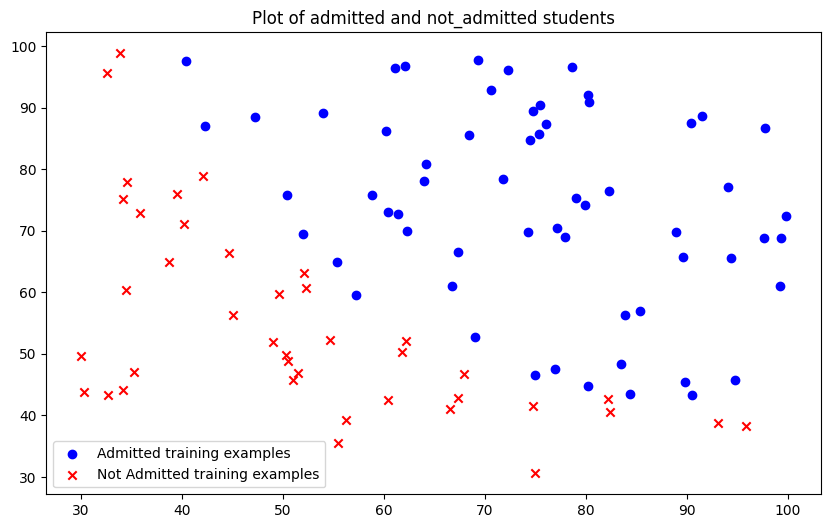

In [17]:
plt.figure(figsize=(10,6))
plt.scatter(X_train[pos,0],X_train[pos,1],marker='o',color='b',label='Admitted training examples')
plt.scatter(X_train[neg,0],X_train[neg,1],marker='x',color='r',label='Not Admitted training examples')
plt.title('Plot of admitted and not_admitted students')
plt.legend()
plt.show()

**Cost function algorithm**

In [8]:
def cost_function(x,y,w,b,lambda_):
    m,n = x.shape
    total_cost = 0
    reg_cost = 0
    for i in range(m):
        y_pred = sigmoid(np.dot(x[i],w) + b)
        total_cost+= (-y[i] * np.log(y_pred)) - ((1-y[i]) * np.log(1-y_pred))
    for j in range(n):
        reg_cost += np.square(w[j])
    reg_cost = reg_cost * (lambda_/2*m)   #regularization 
    total_cost = total_cost / m
    total_cost+=reg_cost
    return total_cost
m,n = X_train.shape
w_init = np.zeros(n)
b_init = 0
lambda_ = 0.7
print('The initial cost function is:', cost_function(X_train,Y_train,w_init,b_init,lambda_))
        

The initial cost function is: 0.6931471805599458


**Computing the partial derivatives**

In [9]:
def gradient(x,y,w,b,lambda_):
    m,n = x.shape
    dj_dw = np.zeros(n)  #partial derivative of the cost function with respect to the weight 
    dj_db = 0   #partial derivative of the cost function with respect to the bias
    for i in range(m):
        y_pred = sigmoid(np.dot(x[i],w)+b)
        error = y_pred - y[i]
        for j in range(n):
            dj_dw[j]+=error * x[i,j]
        dj_db+=error
    dj_dw,dj_db = dj_dw / m , dj_db / m
    for j in range(n):  #the regularization is only used on the weights of the model
        dj_dw[j]+=(lambda_/m) * w[j]
    return dj_dw,dj_db    
    

**Computing the gradient descent of logistic regression**

In [10]:
def gradient_descent(x,y,w_init,b_init,cost_function,gradient,lambda_,alpha,iterations):
    w = copy.deepcopy(w_init)
    b = b_init
    cost_hist = []
    iter_hist = []
    for i in range(iterations):
        dj_dw , dj_db = gradient(x,y,w,b,lambda_)
        w = w - (alpha * dj_dw)
        b = b - (alpha * dj_db)
        cost = cost_function(x,y,w,b,lambda_)
        if i % math.ceil(iterations/10) == 0:  #we record the value of cost function and iteration at every 10 iterations interval
            cost_hist.append(cost)
            iter_hist.append(iterations)
    return w,b,cost_hist,iter_hist        
np.random.seed(1)
w_init = 0.01 * (np.random.rand(2) - 0.5)
b_init = -8

# Some gradient descent settings
iterations = 10000
alpha = 0.001 
lambda_=0.7
final_w,final_b,cost_hist,iter_hist = gradient_descent(X_train,Y_train,w_init,b_init,cost_function,gradient,lambda_,alpha,iterations)

In [14]:
def prediction(w,b,x):
    m,n = x.shape
    predicted = np.zeros(m)
    for i in range(m):
       prediction = sigmoid(np.dot(x[i],w) + b)
       if prediction >=0.5:
           predicted[i] = 1
       else:
           predicted[i] = 0
 
    return predicted   
p = prediction(final_w,final_b,X_train)  

The accuracy of our model is: 92.0


**Plotting the decision boundary**

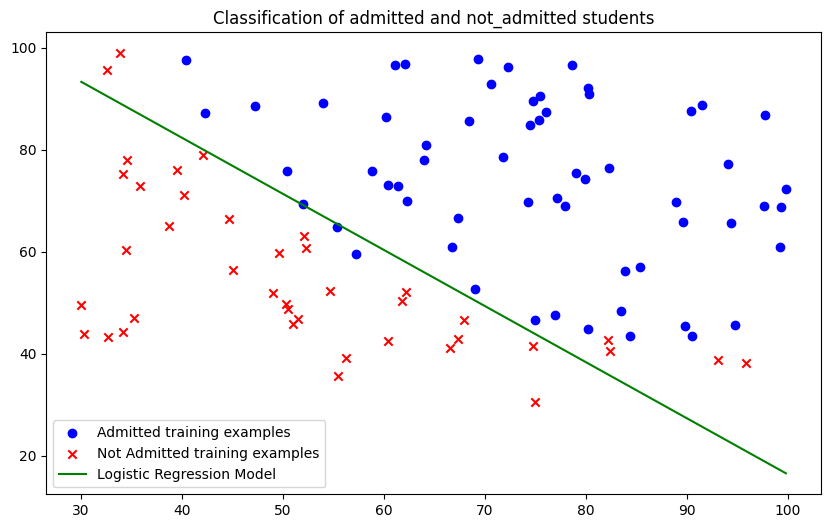

In [18]:
plt.figure(figsize=(10,6))
plt.scatter(X_train[pos,0],X_train[pos,1],marker='o',color='b',label='Admitted training examples')
plt.scatter(X_train[neg,0],X_train[neg,1],marker='x',color='r',label='Not Admitted training examples')

x1 = np.linspace(X_train.min(),X_train.max(),10)
x2 = (-final_b- (x1 * final_w[0])) / final_w[1]   #here we are getting the value of x2 using the help of the final parameters of the model
plt.plot(x1,x2,c='g',label='Logistic Regression Model')
plt.title('Classification of admitted and not_admitted students')
plt.legend()
plt.show()

**As observed from the plot above, the logistic regression model achieves nearly 100% classification accuracy on the training data.**

In [15]:
print(f'The accuracy of our model is: {np.mean(p == Y_train)*100}')

The accuracy of our model is: 92.0
